# Estimación de peso de pollos

## Colegio de Posgraduados

### COA661 Inteligencia Artificial

Profesor: Dr. Juan Manuel González Camacho

Entrega: José Alfredo Martínez

Este notebook muestra el preprocesamiento que se hace en una sola imagen para obtener:

<ol>
    <li>Área (pix^2).</li>
    <li>perímetro (pix).</li>
    <li>Solidez (adimensional).</li>
    <li>Redondez (adimensional).</li>
    <li>Área de polígono convexo (pix^2)</li>
    <li>Eje mayor de elipse (pix)</li>
    <li>Eje menor de elipse (pix)</li>
    <li>Excentricidad (adimensional)</li>
</ol>

In [1]:
# Librerías
import numpy as np
import math

from plantcv import plantcv as pcv
import cv2

## Código

Original: 1.890kg_00001.jpg


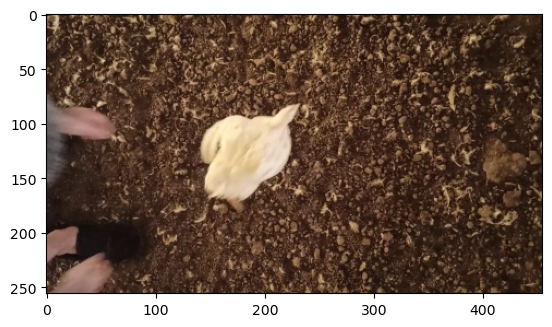

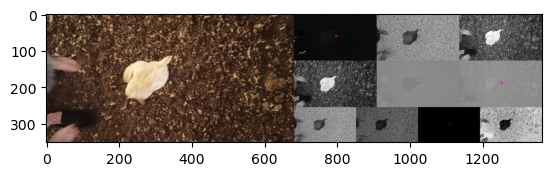

In [2]:
# Configuración
localPath = './Fotogramas/1.890kg_00001.jpg'
imagen, path, archivo = pcv.readimage(localPath)

print('Original: ' + archivo)
pcv.plot_image(imagen)

colorspace_img = pcv.visualize.colorspaces(rgb_img = imagen)
pcv.plot_image(colorspace_img)

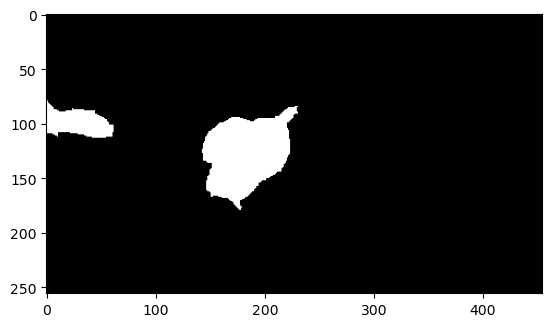

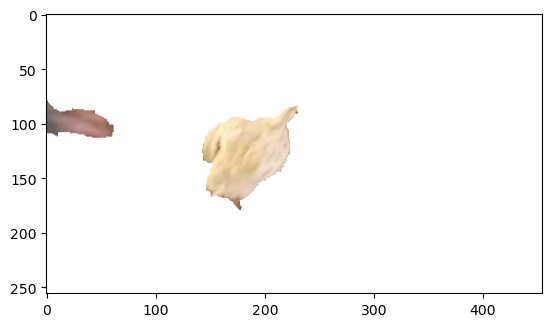

In [4]:
# Extraer el canal l
img_l = pcv.rgb2gray_lab(rgb_img = imagen, channel = 'l')
img_lb = pcv.threshold.otsu(gray_img = img_l, object_type = 'light')

# Eliminar ruido
img_mask01 = pcv.erode(gray_img = img_lb, ksize = 4, i = 1)
img_mask01 = pcv.fill(bin_img = img_mask01, size = 1000)
img_mask01 = pcv.fill_holes(bin_img = img_mask01)

# Imprimir máscara
pcv.plot_image(img_mask01)

imagen2 = pcv.apply_mask(img = imagen, mask = img_mask01, mask_color = 'white')
pcv.plot_image(imagen2)

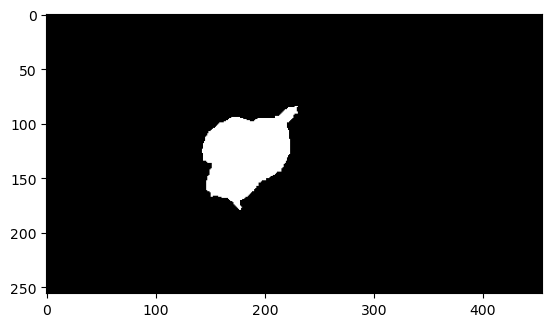

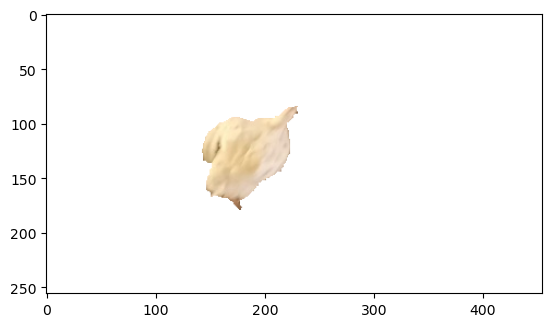

In [5]:
# Limpiar cualquier ruido en los bordes
a = 5
alto = imagen.shape[0]
largo = imagen.shape[1]

roi1 = pcv.roi.rectangle(img = imagen, x = 0, y = 0, h = alto, w = a)
img_mask02 = pcv.roi.filter(mask = img_mask01, roi = roi1, roi_type = 'partial')

roi2 = pcv.roi.rectangle(img = imagen, x = 0, y = 0, h = a, w = largo)
img_mask03 = pcv.roi.filter(mask = img_mask01, roi = roi2, roi_type = 'partial')

roi3 = pcv.roi.rectangle(img = imagen, x = 0, y = alto - a, h = a, w = largo)
img_mask04 = pcv.roi.filter(mask = img_mask01, roi = roi3, roi_type = 'partial')

roi4 = pcv.roi.rectangle(img = imagen, x = largo - a, y = 0, h = alto, w = a)
img_mask05 = pcv.roi.filter(mask = img_mask01, roi = roi4, roi_type = 'partial')

img_maskX = pcv.logical_or(img_mask02, img_mask03)
img_maskX = pcv.logical_or(img_maskX, img_mask04)
img_maskX = pcv.logical_or(img_maskX, img_mask05)

img_mask01 -= img_maskX

# Imprimir máscara
pcv.plot_image(img_mask01)

imagen2 = pcv.apply_mask(img = imagen, mask = img_mask01, mask_color = 'white')
pcv.plot_image(imagen2)

In [6]:
# contar objetos
etiquetas, n = pcv.create_labels(mask = img_mask01)
print('Objetos encontrados: ', n)

Objetos encontrados:  1


Area: 4872.0
perimetro: 331.9066
Solidez: 0.8774
Redondez: 1.7993
Área Polígono: 5552.5
Eje mayor elipse: 100.8757
Eje menor elipse: 67.6967
Excentricidad: 0.7414


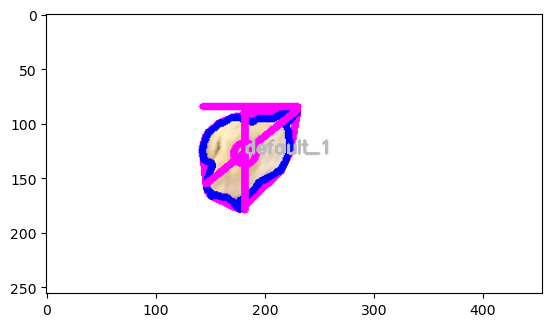

In [7]:
# Datos de análisis del pollo
analysis_image = pcv.analyze.size(img = imagen2, labeled_mask = etiquetas, n_labels = n)

area = pcv.outputs.observations['default_1']['area']['value']
perimetro = pcv.outputs.observations['default_1']['perimeter']['value']

solidez = pcv.outputs.observations['default_1']['solidity']['value']
redondez = (perimetro ** 2) / (4 * math.pi * area)

areaPol = pcv.outputs.observations['default_1']['convex_hull_area']['value']
ejeMayor = pcv.outputs.observations['default_1']['ellipse_major_axis']['value']
ejeMenor = pcv.outputs.observations['default_1']['ellipse_minor_axis']['value']
excentricidad = pcv.outputs.observations['default_1']['ellipse_eccentricity']['value']

print(f'Area: {round(area, 4)}')
print(f'perimetro: {round(perimetro, 4)}')
print(f'Solidez: {round(solidez, 4)}')
print(f'Redondez: {round(redondez, 4)}')
print(f'Área Polígono: {round(areaPol, 4)}')
print(f'Eje mayor elipse: {round(ejeMayor, 4)}')
print(f'Eje menor elipse: {round(ejeMenor, 4)}')
print(f'Excentricidad: {round(excentricidad, 4)}')

pcv.plot_image(analysis_image)